🗺️ Notebook 04: Geographic & Outlier Analysis

Questo notebook esamina la distribuzione territoriale delle vendite e la presenza di anomalie nei dati:

1. Analisi delle vendite e del numero di ordini per Regione, Stato e Città.

1. Confronto tra Media e Mediana delle vendite per rilevare l'asimmetria delle distribuzioni geografiche.

1. Rilevamento degli Outliers (transazioni eccezionalmente alte) utilizzando il metodo dell'Intervallo Interquartile (IQR).

1. Valutazione dell'impatto degli Outliers sui risultati generali dell'azienda.

### 1. Importazione Librerie e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CLEANED_DATA_PATH = '../data/superstore_cleaned.csv'
df = pd.read_csv(CLEANED_DATA_PATH)

print(f"Dataset caricato: {df.shape[0]} righe x {df.shape[1]} colonne.")

Dataset caricato: 9800 righe x 25 colonne.


### 2. Performance delle Vendite per Regione e Stato

In [2]:
# Aggregazione per Regione
region_summary = (
    df.groupby('Region')['Sales']
    .agg(
        Total_Sales=('sum'),
        Avg_Sales=('mean'),
        Median_Sales=('median'),
        Orders_Count=('count')
    )
    .reset_index()
    .sort_values(by='Total_Sales', ascending=False)
)

print("--- SUMMARY PER REGIONE ---")
display(region_summary)

# Top 10 Stati per Vendite Totali
state_summary = (
    df.groupby('State')['Sales']
    .agg(
        Total_Sales=('sum'),
        Avg_Sales=('mean'),
        Median_Sales=('median'),
        Orders_Count=('count')
    )
    .reset_index()
    .sort_values(by='Total_Sales', ascending=False)
)

print("\n--- TOP 10 STATI PER FATTURATO ---")
display(state_summary.head(10))


--- SUMMARY PER REGIONE ---


,Region,Total_Sales,Avg_Sales,Median_Sales,Orders_Count
3,West,710219.6845,226.184613,61.002,3140
1,East,669518.7260,240.401697,54.960,2785
0,Central,492646.9132,216.357889,45.920,2277
2,South,389151.4590,243.524067,54.114,1598



--- TOP 10 STATI PER FATTURATO ---


,State,Total_Sales,Avg_Sales,Median_Sales,Orders_Count
3,California,446306.4635,229.345562,61.040,1946
30,New York,306361.1470,279.271784,60.450,1097
41,Texas,168572.5322,173.250290,36.288,973
45,Washington,135206.8500,268.267560,65.940,504
36,Pennsylvania,116276.6500,199.788058,41.786,582
8,Florida,88436.5320,237.095260,41.472,373
11,Illinois,79236.5170,164.050760,35.856,483
20,Michigan,76136.0740,300.933099,85.520,253
33,Ohio,75130.3500,165.485352,41.763,454
44,Virginia,70636.7200,315.342500,65.250,224


### 3. Asimmetria Geografica: Media vs Mediana

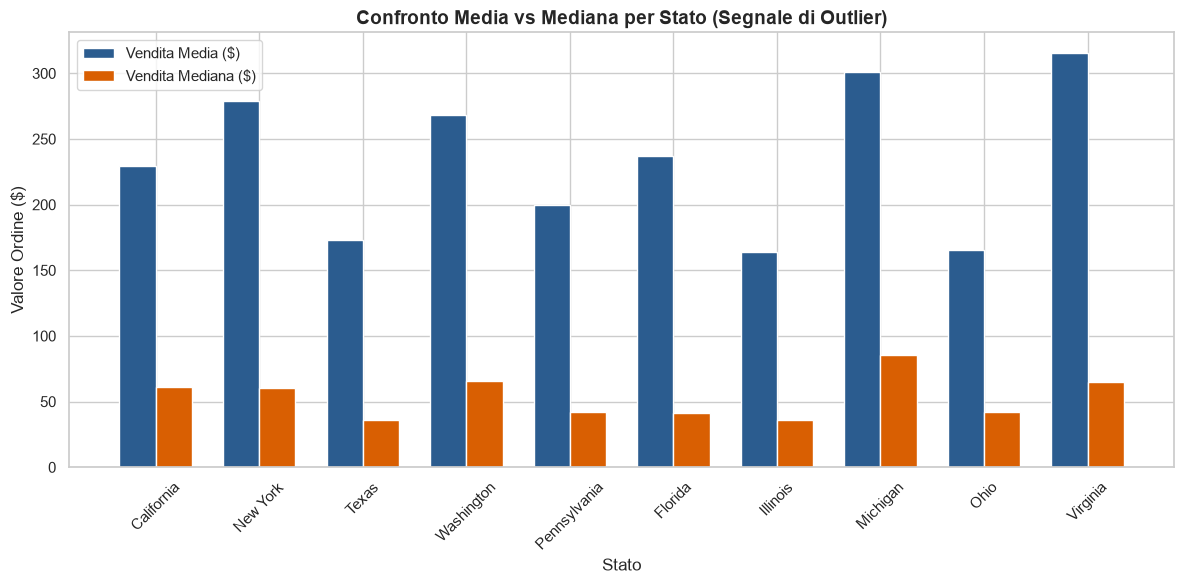

In [3]:
# Grafico di confronto Media vs Mediana nei Top 10 Stati
top10_states = state_summary.head(10)

plt.figure(figsize=(12, 6))
x = np.arange(len(top10_states))
width = 0.35

plt.bar(x - width/2, top10_states['Avg_Sales'], width, label='Vendita Media ($)', color='#2b5c8f')
plt.bar(x + width/2, top10_states['Median_Sales'], width, label='Vendita Mediana ($)', color='#d95f02')

plt.xlabel('Stato')
plt.ylabel('Valore Ordine ($)')
plt.title('Confronto Media vs Mediana per Stato (Segnale di Outlier)', fontsize=14, fontweight='bold')
plt.xticks(x, top10_states['State'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 4. Identificazione degli Outliers tramite metodo IQR

In [4]:
# Calcolo dell'Intervallo Interquartile (IQR) per le Vendite
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtriamo le transazioni definite come Outlier
outliers = df[df['Sales'] > upper_bound]

print(f"--- ANALISI OUTLIERS (Metodo IQR) ---")
print(f"Soglia inferiore (Lower Bound): {lower_bound:.2f}")
print(f"Soglia superiore (Upper Bound): {upper_bound:.2f}")
print(f"Totale transazioni Outlier: {len(outliers)} su {len(df)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Impatto sul Fatturato Totale: {outliers['Sales'].sum():,.2f} $ su {df['Sales'].sum():,.2f} $ ({(outliers['Sales'].sum()/df['Sales'].sum())*100:.2f}%)")

--- ANALISI OUTLIERS (Metodo IQR) ---
Soglia inferiore (Lower Bound): -272.79
Soglia superiore (Upper Bound): 500.64
Totale transazioni Outlier: 1145 su 9800 (11.68%)
Impatto sul Fatturato Totale: 1,454,775.41 $ su 2,261,536.78 $ (64.33%)


### 5. Visualizzazione Boxplot e Distribuzione Outliers

C:\Users\ameli\AppData\Local\Temp\ipykernel_21040\1312678393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Sales', palette='Set2')


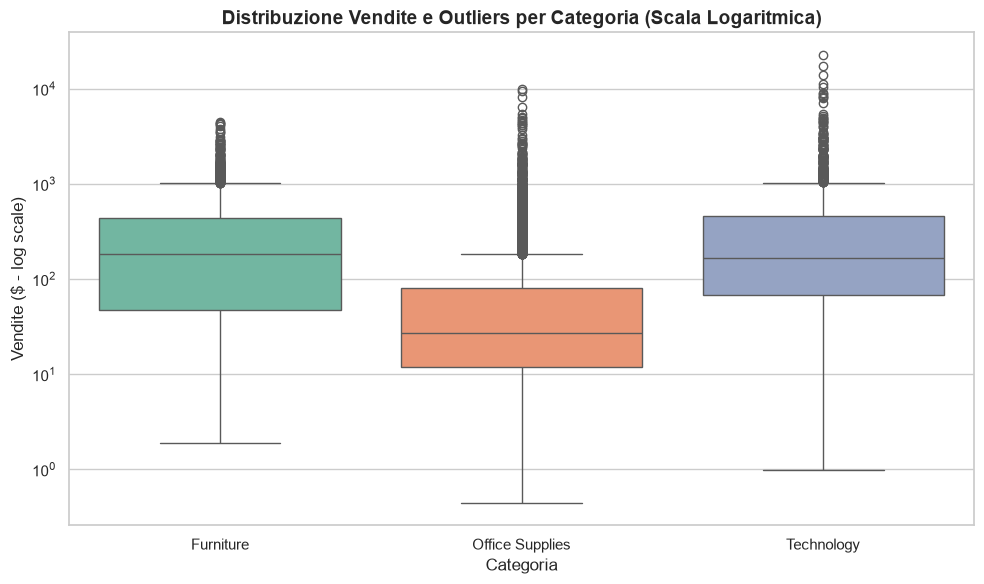


--- TOP 5 SINGOLI ORDINI DI VALORE PIÙ ELEVATO ---


,Order ID,Order Date,Customer Name,State,Category,Sub-Category,Sales
2697,CA-2015-145317,2015-03-18,Sean Miller,Florida,Technology,Machines,22638.480
6826,CA-2017-118689,2017-10-02,Tamara Chand,Indiana,Technology,Copiers,17499.950
8153,CA-2018-140151,2018-03-23,Raymond Buch,Washington,Technology,Copiers,13999.960
2623,CA-2018-127180,2018-10-22,Tom Ashbrook,New York,Technology,Copiers,11199.968
4190,CA-2018-166709,2018-11-17,Hunter Lopez,Delaware,Technology,Copiers,10499.970


In [5]:
# Boxplot per identificare visivamente gli outlier di vendita per Categoria
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Sales', palette='Set2')
plt.yscale('log') # Scala logaritmica per rendere visibile l'ampio range di valori
plt.title('Distribuzione Vendite e Outliers per Categoria (Scala Logaritmica)', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Vendite ($ - log scale)')
plt.tight_layout()
plt.show()

# Top 5 ordini più grandi di tutto il dataset
print("\n--- TOP 5 SINGOLI ORDINI DI VALORE PIÙ ELEVATO ---")
display(df[['Order ID', 'Order Date', 'Customer Name', 'State', 'Category', 'Sub-Category', 'Sales']].nlargest(5, 'Sales'))